In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, make_scorer
import xgboost as xgb
import joblib
from sklearn.inspection import permutation_importance

In [14]:
df = pd.read_csv('../../../data/preprocessed/selected_features_dataset_V2.csv')
X = df.drop(['price_per_m2'], axis=1)
y = df['price_per_m2']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
def gap_sensitive_r2(estimator, X, y):
    """Scores models based on test R² while penalizing large train-test gaps"""
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
    
    estimator.fit(X_train, y_train)
    
    train_r2 = r2_score(y_train, estimator.predict(X_train))
    val_r2 = r2_score(y_val, estimator.predict(X_val))
    gap = abs(train_r2 - val_r2)
    
    # Prioritize test R² (70%) and penalize gaps (30%)
    return 0.7 * val_r2 - 0.3 * gap

In [17]:
param_grid = {
     'n_estimators': [200, 300, 400],  # Increased capacity
    'max_depth': [4, 5, 6],           # Deeper trees
    'learning_rate': [0.01, 0.015],    # Slower learning
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'gamma': [0, 0.1, 0.2],           # More regularization
    'reg_alpha': [0, 0.1, 0.5],       # L1 regularization
    'reg_lambda': [0.5, 1, 1.5]       # L2 regularization
}


In [18]:
xgb_model = xgb.XGBRegressor(random_state=42, n_jobs=-1)
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring=make_scorer(gap_sensitive_r2, greater_is_better=True),
    cv=3,
    verbose=2,
    n_jobs=-1
)

In [19]:
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 4374 candidates, totalling 13122 fits


d:\anaconda\envs\env_v3.10\lib\site-packages\sklearn\model_selection\_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan ... nan nan nan]
  warnings.warn(


GridSearchCV(cv=3,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None...
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=-1, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.7, 0.8, 0.9],
                         'gamma': [0, 0.1, 0.2], 'learning_rate': [0.01, 0.015],
                         'max_depth': [4, 5, 6],
                         'n_estimators': [200, 300, 400],
                         'reg_alpha': [0, 0.1, 0.5],
                         'reg_lambda': [0.5, 1, 1.5],
                         'subsample': [0.7, 0.8, 0.9]},
             scoring=make_scorer(gap_sensitive_r2, response_method='predict'),
             verbose=2)

In [20]:
best_model = grid_search.best_estimator_
print(f"\nBest parameters: {grid_search.best_params_}")


Best parameters: {'colsample_bytree': 0.7, 'gamma': 0, 'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 200, 'reg_alpha': 0, 'reg_lambda': 0.5, 'subsample': 0.7}


In [21]:
def evaluate_model(model, X_train, y_train, X_test, y_test):
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    train_r2 = r2_score(y_train, y_pred_train)
    test_r2 = r2_score(y_test, y_pred_test)
    gap = abs(train_r2 - test_r2)
    
    metrics = {
        'Train R²': train_r2,
        'Test R²': test_r2,
        'Gap': gap,
        'MAE': mean_absolute_error(y_test, y_pred_test),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_test))
    }
    
    print("\nModel Performance:")
    print("="*50)
    for k, v in metrics.items():
        print(f"{k}: {v:.4f}")
    print("="*50)
    
    return metrics

In [22]:
metrics = evaluate_model(best_model, X_train, y_train, X_test, y_test)


Model Performance:
Train R²: 0.8660
Test R²: 0.8591
Gap: 0.0068
MAE: 470.1159
RMSE: 694.0918


In [23]:
y_pred_test = best_model.predict(X_test)

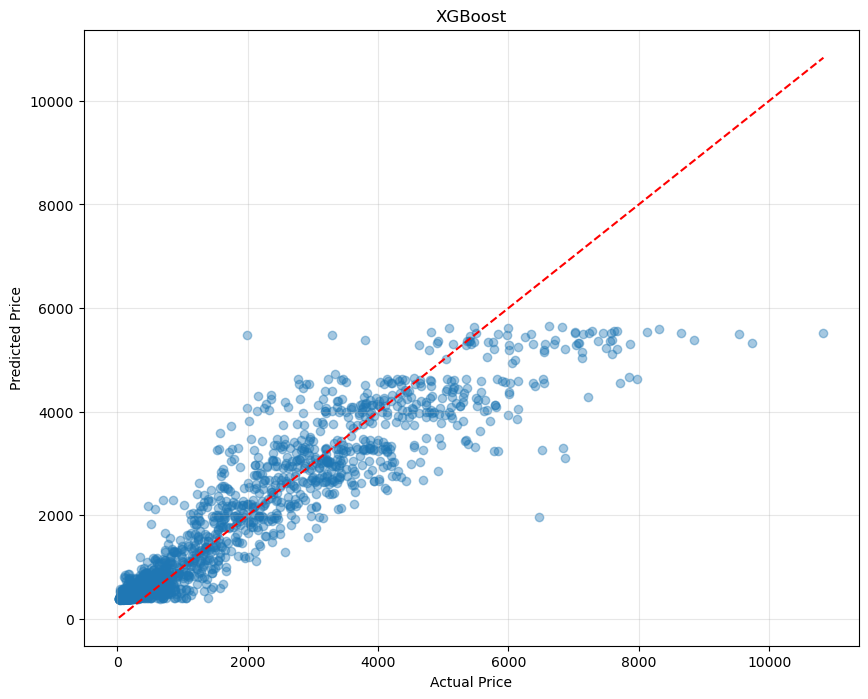

In [24]:
plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred_test, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("XGBoost")
plt.grid(alpha=0.3)
plt.show()

In [25]:
joblib.dump(best_model, "../../../models/xgboost/xgboost_model_label_v6.joblib")

['../../../models/xgboost/xgboost_model_label_v6.joblib']